# Leyenda — Livrable 3 : génération automatique de légendes (CNN + RNN)

### Groupe 2 — Projet Data Science (CESI A5)

---

## 0. Contexte métier — TouNum

**TouNum** est un projet de *numérisation patrimoniale* dont l'objectif est de
constituer automatiquement les **métadonnées** d'un fonds d'images numérisées
(photographies, peintures, schémas, croquis, documents textuels). Annoter
manuellement des dizaines de milliers d'images serait trop coûteux : le projet
repose donc sur un **workflow automatisé** en trois étapes, chacune correspondant
à un livrable.

| Étape | Livrable | Rôle | Modèle | Entrée |
|-------|----------|------|--------|--------|
| **L1** | Livrable 1 | **Classification** (photo / non-photo) | CNN *from scratch* (4 blocs Conv2D 32→64→128→256, BatchNorm + MaxPooling), Adam `1e-4` | 224×224 |
| **L2** | Livrable 2 | **Débruitage** des images dégradées | Auto-encodeur **U-Net**, perte `0.85·MSE + 0.15·(1−SSIM)` | 256×256 |
| **L3** | **Livrable 3 (ce notebook)** | **Génération de légendes** | **InceptionV3 (encodeur) + LSTM (décodeur)** | 299×299 |

Ce livrable final **intègre les trois étapes** (section 9) : une image numérisée est
d'abord classée (L1), nettoyée si nécessaire (L2), puis décrite par une légende (L3)
qui constituera une métadonnée de recherche.

### Schéma du pipeline complet

```
 +--------------------------------------------------------------------+
 |                      PIPELINE TouNum (workflow)                     |
 +--------------------------------------------------------------------+

        Image numerisee
             |
             v
   +-------------------+      Photo ?        +------------------+
   |  L1 : CLASSIF     | -----------------> |  Tri / routage    |
   |  CNN from scratch |                     +------------------+
   |  224 x 224        |
   +---------+---------+
             | (si image degradee / bruitee)
             v
   +-------------------+
   |  L2 : DEBRUITAGE  |   Auto-encodeur U-Net  (256x256, 0.85*MSE + 0.15*(1-SSIM))
   +---------+---------+
             | image nette
             v
   +-------------------+
   |  L3 : CAPTIONING  |   Encodeur InceptionV3 (299x299 -> 2048-d)
   |  CNN  +  RNN      |   Decodeur Embedding(256) + LSTM(256)
   +---------+---------+   ->  "<start> a dog runs on the grass <end>"
             |
             v
     Legende textuelle  (metadonnee indexable)
```

---
## 1. Imports et configuration centralisée

**Quoi** — charger les librairies et regrouper **tous les hyperparamètres** au même endroit.
**Pourquoi** — un point de configuration unique rend le notebook reproductible
(graine = 42) et facile à régler sans toucher au reste du code.
**Comment** — une cellule d'imports, puis une cellule de configuration regroupant
chemins, dimensions et hyperparamètres.

| Librairie | Rôle dans le livrable |
|-----------|------------------------|
| `numpy`, `pandas` | manipulation des tableaux et des annotations |
| `matplotlib`, `PIL` | visualisation et chargement des images |
| `tqdm` | barre de progression (extraction des features) |
| `tensorflow` / `keras` | encodeur CNN, décodeur LSTM, entraînement |
| `InceptionV3` | encodeur d'images pré-entraîné ImageNet (gelé) |
| `nltk` (`bleu_score`) | métriques d'évaluation BLEU-1 / BLEU-2 |
| `scikit-learn` | découpage train / validation |

In [1]:
# Librairies standard & data
import os, json, re, time, math, pickle, collections
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Dropout, Add
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# NLP / metriques
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split

print('Imports OK - TensorFlow', tf.__version__)

Imports OK - TensorFlow 2.10.0


In [2]:
# -----------------------------------------------------------------
# CONFIGURATION CENTRALISEE
# Tous les chemins et hyperparametres du livrable 3 sont definis ici
# pour faciliter les reglages sans modifier le reste du code.
# -----------------------------------------------------------------

# --- Reproductibilite (seed globale) ---
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# --- Chemins du projet (racine absolue, fixee pour cet environnement) ---
PROJECT_ROOT = Path(r"C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github")

DATA_RAW      = PROJECT_ROOT / 'data' / 'raw'
IMAGES_DIR    = DATA_RAW / 'train2014'
ANN_DIR       = DATA_RAW / 'annotations'
CAPTIONS_JSON = ANN_DIR / 'captions_train2014.json'
FEATURES_DIR  = PROJECT_ROOT / 'features'
MODELS_DIR    = PROJECT_ROOT / 'src' / 'models'
FIGURES_DIR   = PROJECT_ROOT / 'notebooks' / 'figures'
for d in (FEATURES_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FEATURES_NPY  = FEATURES_DIR / 'image_features.npy'   # features CNN pre-extraites
MODEL_PATH    = MODELS_DIR / 'captioning_model.keras' # meilleur modele (ModelCheckpoint)
TOKENIZER_PKL = MODELS_DIR / 'captioning_tokenizer.pkl'
HISTORY_JSON  = MODELS_DIR / 'captioning_history.json' # historique (fallback courbes)

# --- Modeles des livrables precedents (workflow, section 9) ---
L1_MODEL_PATH = MODELS_DIR / 'cnn_scratch.keras'                # Classification (L1)
# Debruitage (L2) : le U-Net a ete sauvegarde avec Keras 3 (format .keras illisible
# par TF 2.10). On privilegie la version reconstruite en HDF5 (unet_model_tf210.h5),
# numeriquement identique a l'originale ; a defaut on retombe sur le .keras d'origine.
_L2_H5        = PROJECT_ROOT / 'notebooks' / 'unet_model_tf210.h5'
L2_MODEL_PATH = _L2_H5 if _L2_H5.exists() else PROJECT_ROOT / 'notebooks' / 'unet_model.keras'  # Debruitage (L2)

# --- Echantillonnage du dataset MS COCO ---
MAX_IMAGES = 8000          # sous-echantillon (images deja extraites dans data/raw/train2014/)

# --- Encodeur CNN (InceptionV3, gele) ---
IMG_SIZE    = 299          # taille d'entree InceptionV3
FEATURE_DIM = 2048         # dimension du vecteur de features (pooling='avg')
FEAT_BATCH  = 8            # taille de batch pour l'extraction des features

# --- Vocabulaire / texte ---
VOCAB_SIZE = 5000          # taille du vocabulaire (tokens speciaux inclus)
PAD_TOK, START_TOK, END_TOK, UNK_TOK = '<pad>', '<start>', '<end>', '<unk>'

# --- Decodeur RNN ---
EMBED_DIM   = 256          # dimension des embeddings de mots
LSTM_UNITS  = 256          # unites de la couche LSTM
DENSE_UNITS = 256          # unites de la couche de fusion
DROPOUT     = 0.5

# --- Entrainement ---
EPOCHS        = 15
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
VAL_SPLIT     = 0.2        # part des IMAGES reservee a la validation

# --- Evaluation ---
N_EVAL_IMAGES = 300        # nb d'images de validation pour le calcul du BLEU
N_SHOW        = 8          # nb d'exemples qualitatifs affiches

# --- GPU : croissance memoire (evite de saturer la GTX 1050) ---
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try: tf.config.experimental.set_memory_growth(g, True)
    except Exception as e: print('  set_memory_growth:', e)

print('Seed global     :', SEED)
print('GPU             :', [g.name for g in gpus] if gpus else 'aucun (CPU)')
print('Images dir      :', IMAGES_DIR, '(existe:', IMAGES_DIR.exists(), ')')
print('Captions JSON   :', CAPTIONS_JSON.exists())
print('Hyperparams     : vocab=%d  embed=%d  lstm=%d  epochs=%d  batch=%d  lr=%.0e'
      % (VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, EPOCHS, BATCH_SIZE, LEARNING_RATE))

Seed global     : 42
GPU             : ['/physical_device:GPU:0']
Images dir      : C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\data\raw\train2014 (existe: True )
Captions JSON   : True
Hyperparams     : vocab=5000  embed=256  lstm=256  epochs=15  batch=64  lr=1e-03


In [3]:
# -----------------------------------------------------------------
# STYLE GRAPHIQUE - palette unifiee pour toutes les figures du notebook
# -----------------------------------------------------------------
C_TRAIN  = '#2c7fb8'   # courbe / barres d'entrainement
C_VAL    = '#e34a33'   # courbe de validation
C_ACCENT = '#31a354'   # mise en evidence (meilleure epoque, BLEU-2)
C_BAR    = '#d95f5f'   # barres neutres (ecart de generalisation)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':        10,
})
print('Palette : C_TRAIN=%s  C_VAL=%s  C_ACCENT=%s  C_BAR=%s'
      % (C_TRAIN, C_VAL, C_ACCENT, C_BAR))

Palette : C_TRAIN=#2c7fb8  C_VAL=#e34a33  C_ACCENT=#31a354  C_BAR=#d95f5f


---
## 2. Chargement et exploration de MS COCO

**Quoi** — charger les annotations COCO et les associer aux images du sous-échantillon.
**Pourquoi** — mesurer le volume (images, légendes), la longueur des légendes et
l'étendue du vocabulaire afin de dimensionner correctement le modèle.
**Comment** — lecture du fichier `captions_train2014.json`, jointure avec les images
réellement présentes dans `data/raw/train2014/`, puis statistiques et exemples.

In [4]:
# Chargement des annotations COCO (legendes)
with open(CAPTIONS_JSON, encoding='utf-8') as f:
    coco = json.load(f)

# Correspondance image_id -> nom de fichier
id2file = {img['id']: img['file_name'] for img in coco['images']}

# On ne conserve que les legendes des images reellement extraites localement
available = set(os.listdir(IMAGES_DIR))
records = []
for a in coco['annotations']:
    fn = id2file.get(a['image_id'])
    if fn in available:
        records.append({'image_id': a['image_id'],
                        'file_name': fn,
                        'caption': a['caption'].strip()})
df = pd.DataFrame(records)

# Securite : si plus de MAX_IMAGES images, on tronque de maniere deterministe
keep = sorted(df['image_id'].unique())[:MAX_IMAGES]
df = df[df['image_id'].isin(set(keep))].reset_index(drop=True)

print('Images uniques :', df['image_id'].nunique())
print('Legendes       :', len(df))
df.head()

Images uniques : 8000
Legendes       : 40019


,image_id,file_name,caption
0,116100,COCO_train2014_000000116100.jpg,A panoramic view of a kitchen and all of its a...
1,116100,COCO_train2014_000000116100.jpg,A panoramic photo of a kitchen and dining room
2,302443,COCO_train2014_000000302443.jpg,Several metal balls sit in the sand near a gro...
3,18691,COCO_train2014_000000018691.jpg,A few people sit on a dim transportation system.
4,479495,COCO_train2014_000000479495.jpg,A bicycle is parked by a bench at night.


**Statistiques descriptives** : nombre de légendes par image et distribution des longueurs.

In [5]:
n_images = df['image_id'].nunique()
n_caps   = len(df)
df['n_words'] = df['caption'].str.split().apply(len)

print('Images               :', n_images)
print('Legendes             :', n_caps)
print('Legendes / image     : %.2f' % (n_caps / n_images))
print('Longueur (mots)      : min=%d  moy=%.1f  med=%d  max=%d'
      % (df['n_words'].min(), df['n_words'].mean(),
         df['n_words'].median(), df['n_words'].max()))
print()
print(df['n_words'].describe().round(2))

Images               : 8000
Legendes             : 40019
Legendes / image     : 5.00
Longueur (mots)      : min=7  moy=10.5  med=10  max=49

count    40019.00
mean        10.46
std          2.38
min          7.00
25%          9.00
50%         10.00
75%         11.00
max         49.00
Name: n_words, dtype: float64


**Histogramme des longueurs de légendes** — guide le choix de `MAX_LEN` (section 3).

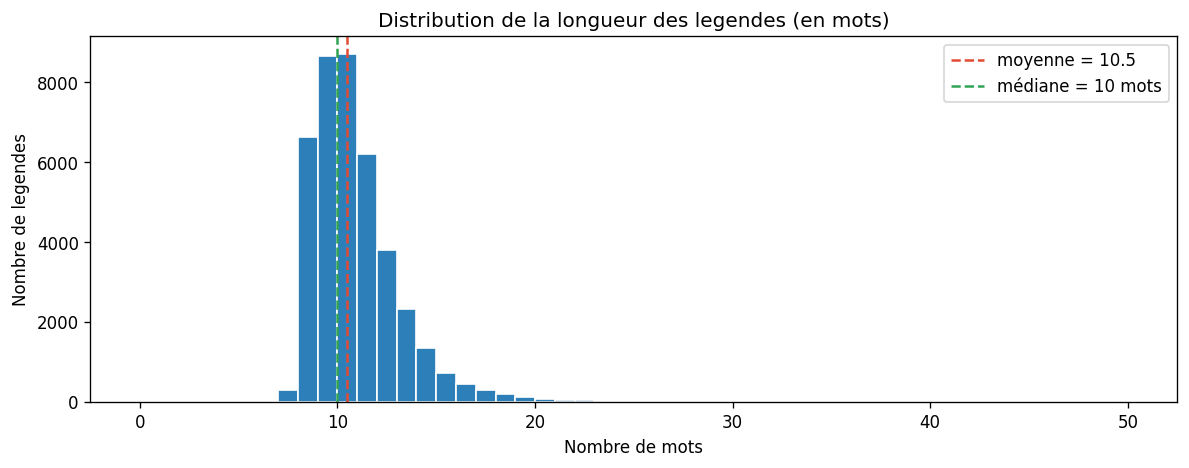

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['n_words'], bins=range(0, df['n_words'].max() + 2),
        color=C_TRAIN, edgecolor='white')
ax.axvline(df['n_words'].mean(), color=C_VAL, linestyle='--',
           label='moyenne = %.1f' % df['n_words'].mean())
ax.axvline(df['n_words'].median(), color=C_ACCENT, linestyle='--',
           label='médiane = %.0f mots' % df['n_words'].median())
ax.set_title("Distribution de la longueur des legendes (en mots)")
ax.set_xlabel('Nombre de mots'); ax.set_ylabel("Nombre de legendes")
ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / 'l3_hist_longueurs.png', dpi=120, bbox_inches='tight')
plt.show()

**Exemples** — quelques images accompagnées de l'une de leurs légendes de référence.

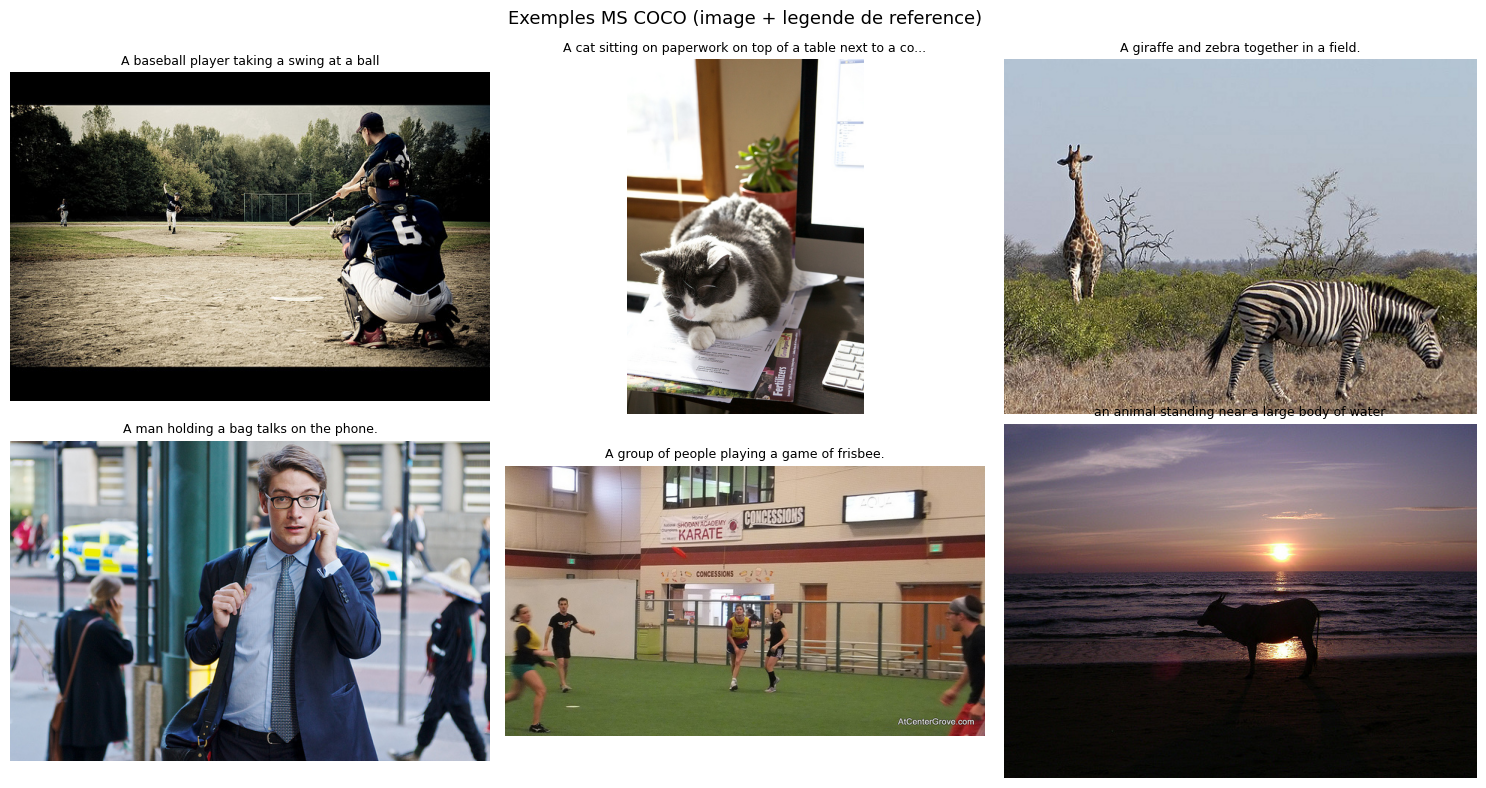

In [7]:
sample = df.drop_duplicates('image_id').sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(Image.open(IMAGES_DIR / row['file_name']))
    ax.axis('off')
    cap = row['caption']
    ax.set_title(cap if len(cap) < 60 else cap[:57] + '...', fontsize=9)
plt.suptitle("Exemples MS COCO (image + legende de reference)", fontsize=13)
plt.tight_layout(); plt.show()

---
## 3. Prétraitement du texte

**Quoi** — nettoyer les légendes, construire le vocabulaire et encoder chaque légende
en séquence d'entiers.
**Pourquoi** — le LSTM opère sur des indices entiers ; il faut donc un vocabulaire borné
(5000 mots), des tokens spéciaux (`<start>`, `<end>`, `<unk>`, `<pad>`) et un *padding*
à longueur fixe.
**Comment** — normalisation (minuscules, ponctuation retirée), encadrement par
`<start>` / `<end>`, comptage des fréquences, puis dictionnaires `word2idx` / `idx2word`.

In [8]:
# Nettoyage : minuscules, on ne garde que les lettres, espaces normalises
def clean_caption(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]+", ' ', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

df['clean'] = df['caption'].apply(clean_caption)
# Encadrement par les tokens de debut / fin de sequence
df['seq_text'] = START_TOK + ' ' + df['clean'] + ' ' + END_TOK

print('Avant :', df['caption'].iloc[0])
print('Apres :', df['seq_text'].iloc[0])

Avant : A panoramic view of a kitchen and all of its appliances.
Apres : <start> a panoramic view of a kitchen and all of its appliances <end>


**Construction du vocabulaire** : on retient les `VOCAB_SIZE − 4` mots les plus
fréquents, complétés par les 4 tokens spéciaux. Les mots hors-vocabulaire sont
remplacés par `<unk>`.

In [9]:
# Comptage des frequences sur le corpus nettoye
counter = collections.Counter()
for t in df['clean']:
    counter.update(t.split())

n_special   = 4
most_common = [w for w, _ in counter.most_common(VOCAB_SIZE - n_special)]

# Dictionnaires : 0 reserve au padding (compatible Embedding mask_zero)
idx2word = {0: PAD_TOK, 1: START_TOK, 2: END_TOK, 3: UNK_TOK}
for i, w in enumerate(most_common, start=n_special):
    idx2word[i] = w
word2idx = {w: i for i, w in idx2word.items()}
vocab_size = len(word2idx)

print('Mots distincts dans le corpus :', len(counter))
print('Taille du vocabulaire retenu  :', vocab_size)
print('Exemple word2idx :', {w: word2idx[w] for w in ['<start>', '<end>', 'a', 'dog'] if w in word2idx})

Mots distincts dans le corpus : 8653
Taille du vocabulaire retenu  : 5000
Exemple word2idx : {'<start>': 1, '<end>': 2, 'a': 4, 'dog': 47}


**Encodage et longueur maximale** : `MAX_LEN` est fixée au 95ᵉ percentile des
longueurs (compromis entre couverture et coût mémoire) ; les séquences plus longues
sont tronquées.

In [10]:
# Choix de MAX_LEN au 95e percentile (en tokens, <start>/<end> compris)
tok_lengths = df['seq_text'].str.split().apply(len)
MAX_LEN = int(np.percentile(tok_lengths, 95))
print('MAX_LEN (95e percentile) :', MAX_LEN)

# Encodage en indices entiers, avec troncature a MAX_LEN
def encode(seq_text):
    ids = [word2idx.get(w, word2idx[UNK_TOK]) for w in seq_text.split()]
    return ids[:MAX_LEN]

df['seq'] = df['seq_text'].apply(encode)

# Statistique de couverture : proportion de tokens connus (hors <unk>)
n_unk   = sum(s.count(word2idx[UNK_TOK]) for s in df['seq'])
n_total = sum(len(s) for s in df['seq'])
print('Tokens totaux        :', n_total)
print('Couverture vocabulaire : %.2f%% (taux <unk> = %.2f%%)'
      % (100 * (1 - n_unk / n_total), 100 * n_unk / n_total))

# Sauvegarde du tokenizer (reutilise a l'inference / workflow)
with open(TOKENIZER_PKL, 'wb') as f:
    pickle.dump({'word2idx': word2idx, 'idx2word': idx2word,
                 'max_len': MAX_LEN, 'vocab_size': vocab_size}, f)
print('Tokenizer sauvegarde ->', TOKENIZER_PKL)

MAX_LEN (95e percentile) : 17
Tokens totaux        : 494616
Couverture vocabulaire : 99.23% (taux <unk> = 0.77%)
Tokenizer sauvegarde -> C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_tokenizer.pkl


---
## 4. Pré-extraction des features CNN (InceptionV3)

**Quoi** — calculer une fois pour toutes le vecteur 2048-d de chaque image avec
InceptionV3 gelé, puis le sauvegarder dans `features/image_features.npy`.
**Pourquoi** — l'encodeur étant **gelé** (`trainable=False`), ses sorties sont
constantes : les pré-calculer évite de repasser les images dans le CNN à chaque époque
et accélère considérablement l'entraînement sur une GTX 1050.
**Comment** — `InceptionV3(include_top=False, pooling='avg')`, prétraitement
`preprocess_input`, extraction par lots avec barre `tqdm`, puis mise en cache `.npy`.

In [11]:
# Encodeur CNN : InceptionV3 pre-entraine ImageNet, sans tete de classification,
# avec global average pooling -> vecteur de 2048 dimensions. Entierement gele.
def build_encoder():
    base = InceptionV3(include_top=False, weights='imagenet', pooling='avg')
    base.trainable = False
    enc = Model(base.input, base.output, name='inceptionv3_encoder')
    enc.trainable = False          # on gele aussi le conteneur (coherence)
    return enc

encoder = build_encoder()
n_train = sum(1 for w in encoder.trainable_weights)
print('Encodeur InceptionV3 - sortie :', encoder.output_shape,
      '| trainable :', encoder.trainable, '| poids entrainables :', n_train)

Encodeur InceptionV3 - sortie : (None, 2048) | trainable : False | poids entrainables : 0


In [12]:
# Chargement + pretraitement d'une image au format attendu par InceptionV3
def load_image(file_name):
    img = load_img(IMAGES_DIR / file_name, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img)
    return preprocess_input(arr)            # mise a l'echelle [-1, 1]

unique_files = df.drop_duplicates('file_name')['file_name'].tolist()

if FEATURES_NPY.exists():
    features = np.load(FEATURES_NPY, allow_pickle=True).item()
    print('Features chargees depuis le cache :', len(features), 'images')
else:
    features = {}
    for i in tqdm(range(0, len(unique_files), FEAT_BATCH), desc='Extraction features'):
        chunk = unique_files[i:i + FEAT_BATCH]
        batch = np.stack([load_image(fn) for fn in chunk])
        vecs  = encoder.predict(batch, verbose=0)
        for fn, v in zip(chunk, vecs):
            features[fn] = v.astype('float32')
    np.save(FEATURES_NPY, features)
    print('Features sauvegardees ->', FEATURES_NPY)

print('Nombre d images    :', len(features))
print('Dimension features :', next(iter(features.values())).shape)

Features chargees depuis le cache : 8000 images
Nombre d images    : 8000
Dimension features : (2048,)


---
## 5. Générateur de données (teacher forcing)

**Quoi** — transformer chaque légende en plusieurs exemples (image + début de phrase
→ mot suivant) et les fournir par lots au modèle.
**Pourquoi** — le décodeur est entraîné en **teacher forcing** : à chaque pas de temps,
on lui fournit le **vrai** préfixe de la légende (et non sa propre prédiction) et on lui
demande de prédire le **mot suivant**. Ce procédé stabilise et accélère l'apprentissage.

```
Legende : <start> a dog runs <end>
  entree image + [<start>]                      -> cible : a
  entree image + [<start>, a]                    -> cible : dog
  entree image + [<start>, a, dog]               -> cible : runs
  entree image + [<start>, a, dog, runs]         -> cible : <end>
```

**Comment** — on matérialise la liste des couples (préfixe → mot cible), puis une
classe `keras.utils.Sequence` construit les lots : features image, séquence
*paddée* et cible *one-hot* (pour `categorical_crossentropy`).

In [13]:
# Construction des couples (prefixe -> mot suivant) pour un sous-ensemble d'images
def build_samples(sub_df):
    keys, seqs, targets = [], [], []
    for row in sub_df.itertuples(index=False):
        seq = row.seq
        for t in range(1, len(seq)):
            keys.append(row.file_name)   # cle vers les features image
            seqs.append(seq[:t])         # prefixe
            targets.append(seq[t])       # mot a predire
    return keys, seqs, targets

# Generateur de batchs (teacher forcing)
class CaptionSequence(Sequence):
    def __init__(self, keys, seqs, targets, features, max_len, vocab_size,
                 batch_size, shuffle=True, seed=SEED):
        self.keys, self.seqs, self.targets = keys, seqs, targets
        self.features, self.max_len, self.vocab_size = features, max_len, vocab_size
        self.batch_size, self.shuffle = batch_size, shuffle
        self.rng = np.random.RandomState(seed)
        self.order = np.arange(len(self.targets))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.targets) / self.batch_size)

    def __getitem__(self, idx):
        sl = self.order[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_img = np.stack([self.features[self.keys[i]] for i in sl])
        X_seq = pad_sequences([self.seqs[i] for i in sl],
                              maxlen=self.max_len, padding='post')
        y = to_categorical([self.targets[i] for i in sl], num_classes=self.vocab_size)
        return (X_img, X_seq), y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

print('Classe CaptionSequence definie (teacher forcing, cible one-hot).')

Classe CaptionSequence definie (teacher forcing, cible one-hot).


---
## 6. Architecture du réseau (encodeur-décodeur par fusion)

**Quoi** — définir le modèle de génération de légendes : une branche image, une branche
texte, fusionnées par addition, puis une sortie softmax sur le vocabulaire.
**Pourquoi** — le modèle *merge* (fusion par `Add`) est léger et bien adapté à un GPU
modeste : l'image (déjà encodée en 2048-d) et l'état du LSTM sont projetés dans un
même espace de 256 dimensions, puis combinés pour prédire le mot suivant.
**Comment** — API fonctionnelle Keras (schéma ci-dessous), `model.summary()` et un
tableau justifiant chaque couche.

### Schéma de l'architecture

```
  Image (299x299x3)                          Sequence de mots (<start> ...)
        |                                              |
        v                                              v
  InceptionV3 (gele)                          Embedding(vocab, 256, mask_zero)
  pooling='avg' -> 2048                                |
        |                                          Dropout(0.5)
   [features 2048]  (pre-extraites, sec. 4)            |
        |                                           LSTM(256)
   Dropout(0.5)                                        |
        |                                              |
   Dense(256, relu) ........ branche image     branche texte ........ [256]
            \                                        /
             \                                      /
              \-------->  Add()  (fusion)  <-------/
                              |
                       Dense(256, relu)
                              |
                   Dense(vocab_size, softmax)
                              |
                       P(mot suivant)
```

In [14]:
# Architecture encodeur-decodeur par fusion (API fonctionnelle Keras)
def build_captioning_model(vocab_size, max_len, feature_dim=FEATURE_DIM):
    # --- Branche image : features 2048-d pre-extraites ---
    img_in = Input(shape=(feature_dim,), name='image_features')
    fi = Dropout(DROPOUT, name='img_dropout')(img_in)
    fi = Dense(DENSE_UNITS, activation='relu', name='img_dense')(fi)

    # --- Branche texte : embedding + LSTM ---
    txt_in = Input(shape=(max_len,), name='caption_seq')
    se = Embedding(vocab_size, EMBED_DIM, mask_zero=True, name='embedding')(txt_in)
    se = Dropout(DROPOUT, name='seq_dropout')(se)
    se = LSTM(LSTM_UNITS, name='lstm')(se)

    # --- Fusion par addition + sortie softmax ---
    dec = Add(name='fusion_add')([fi, se])
    dec = Dense(DENSE_UNITS, activation='relu', name='decoder_dense')(dec)
    out = Dense(vocab_size, activation='softmax', name='output')(dec)

    model = Model(inputs=[img_in, txt_in], outputs=out, name='captioning_cnn_rnn')
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))
    return model

caption_model = build_captioning_model(vocab_size, MAX_LEN)
caption_model.summary()

Model: "captioning_cnn_rnn"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 caption_seq (InputLayer)       [(None, 17)]         0           []                               
                                                                                                  
 image_features (InputLayer)    [(None, 2048)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 17, 256)      1280000     ['caption_seq[0][0]']            
                                                                                                  
 img_dropout (Dropout)          (None, 2048)         0           ['image_features[0][0]']         
                                                                                 

### Justification des couches

| Couche | Rôle | Justification |
|--------|------|---------------|
| `Input(2048)` | features image | sortie de l'encodeur InceptionV3 gelé (sec. 4) |
| `Dropout(0.5)` (image) | régularisation | limite le sur-apprentissage sur les features |
| `Dense(256, relu)` | projection image | aligne l'image sur la dimension du LSTM |
| `Embedding(vocab, 256, mask_zero)` | représentation des mots | vecteurs denses appris ; `mask_zero` ignore le padding |
| `Dropout(0.5)` (texte) | régularisation | réduit la dépendance à des mots isolés |
| `LSTM(256)` | mémoire du préfixe | encode le contexte déjà généré de la phrase |
| `Add()` | fusion | combine image et texte dans un même espace 256-d |
| `Dense(256, relu)` | décodage | mélange non-linéaire des deux modalités |
| `Dense(vocab, softmax)` | sortie | distribution de probabilité sur le mot suivant |

---
## 7. Entraînement

**Quoi** — découper les données en train / validation au niveau **image** (pour éviter
toute fuite), puis entraîner le décodeur.
**Pourquoi** — séparer par image empêche qu'une légende d'un même cliché ne se retrouve
à la fois en entraînement et en validation. Les callbacks gèrent l'arrêt anticipé, la
sauvegarde du meilleur modèle et la réduction du taux d'apprentissage.
**Comment** — `train_test_split` sur les `file_name`, deux `CaptionSequence`, puis `fit`
avec `EarlyStopping`, `ModelCheckpoint` et `ReduceLROnPlateau`.

In [15]:
# Decoupage train / validation AU NIVEAU IMAGE (evite la fuite de donnees)
all_files = df.drop_duplicates('file_name')['file_name'].tolist()
train_files, val_files = train_test_split(all_files, test_size=VAL_SPLIT, random_state=SEED)
train_files, val_files = set(train_files), set(val_files)

train_df = df[df['file_name'].isin(train_files)].reset_index(drop=True)
val_df   = df[df['file_name'].isin(val_files)].reset_index(drop=True)
print('Images   train / val :', len(train_files), '/', len(val_files))
print('Legendes train / val :', len(train_df), '/', len(val_df))

# Materialisation des couples (teacher forcing)
tr_keys, tr_seqs, tr_tgt = build_samples(train_df)
va_keys, va_seqs, va_tgt = build_samples(val_df)
print('Echantillons train / val :', len(tr_tgt), '/', len(va_tgt))

train_seq = CaptionSequence(tr_keys, tr_seqs, tr_tgt, features, MAX_LEN, vocab_size,
                            BATCH_SIZE, shuffle=True)
val_seq   = CaptionSequence(va_keys, va_seqs, va_tgt, features, MAX_LEN, vocab_size,
                            BATCH_SIZE, shuffle=False)
print('Steps / epoch (train) :', len(train_seq))

Images   train / val : 6400 / 1600
Legendes train / val : 32012 / 8007
Echantillons train / val : 363502 / 91095
Steps / epoch (train) : 5680


In [16]:
# Callbacks : arret anticipe, sauvegarde du meilleur modele, reduction du LR
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

t0 = time.time()
history = caption_model.fit(
    train_seq,
    validation_data=val_seq,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
# Sauvegarde de l'historique : permet de retracer les courbes meme apres un
# redemarrage du noyau (l'objet `history` en memoire serait alors perdu).
with open(HISTORY_JSON, 'w', encoding='utf-8') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)
print('Entrainement termine en %.1f min' % ((time.time() - t0) / 60))

Epoch 1/15
5680/5680 [==============================] - ETA: 0s - loss: 3.7623
Epoch 1: val_loss improved from inf to 3.30109, saving model to C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_model.keras
5680/5680 [==============================] - 190s 32ms/step - loss: 3.7623 - val_loss: 3.3011 - lr: 0.0010
Epoch 2/15
5679/5680 [============================>.] - ETA: 0s - loss: 3.0432
Epoch 2: val_loss improved from 3.30109 to 3.17482, saving model to C:\Users\matis\OneDrive - Association Cesi Viacesi mail\[3] CESI\A5\Projet Data Science\Projet Github\src\models\captioning_model.keras
5680/5680 [==============================] - 155s 27ms/step - loss: 3.0432 - val_loss: 3.1748 - lr: 0.0010
Epoch 3/15
5679/5680 [============================>.] - ETA: 0s - loss: 2.8173
Epoch 3: val_loss did not improve from 3.17482
5680/5680 [==============================] - 170s 30ms/step - loss: 2.8173 - val_loss: 3.1803 - lr

**Courbes de perte** — suivi de la convergence (entraînement vs validation) et de
l'écart de généralisation époque par époque.

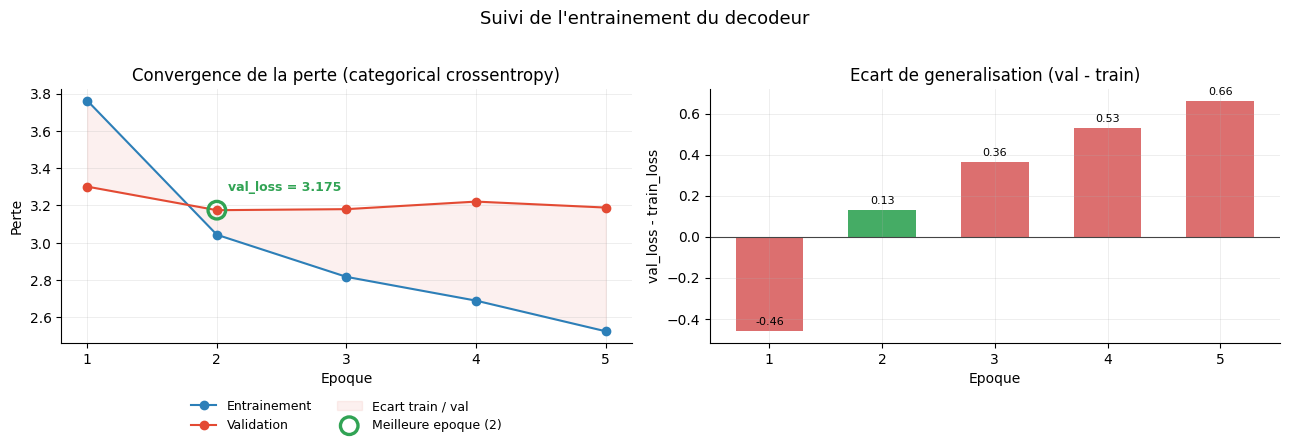

In [17]:
# Courbes de perte en deux panneaux (synthese de l'entrainement).
# Chargement robuste de l'historique : objet `history` en memoire si disponible,
# sinon relecture du JSON sauvegarde (cas d'un noyau redemarre).
try:
    hist = history.history
except NameError:
    with open(HISTORY_JSON, encoding='utf-8') as f:
        hist = json.load(f)

train_loss = np.asarray(hist['loss'], dtype=float)
val_loss   = np.asarray(hist['val_loss'], dtype=float)
epochs     = np.arange(1, len(train_loss) + 1)        # epoques numerotees 1, 2, 3, ...
best       = int(np.argmin(val_loss))                 # meilleure epoque (val_loss min)
gap        = val_loss - train_loss                    # ecart de generalisation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panneau 1 : courbes train vs validation ---
ax1.plot(epochs, train_loss, marker='o', color=C_TRAIN, label='Entrainement')
ax1.plot(epochs, val_loss,   marker='o', color=C_VAL,   label='Validation')
ax1.fill_between(epochs, train_loss, val_loss, color=C_VAL, alpha=0.08,
                 label='Ecart train / val')
ax1.scatter([epochs[best]], [val_loss[best]], s=160, facecolor='none',
            edgecolor=C_ACCENT, linewidth=2.4, zorder=5,
            label='Meilleure epoque (%d)' % epochs[best])
ax1.annotate('val_loss = %.3f' % val_loss[best],
             xy=(epochs[best], val_loss[best]), xytext=(8, 14),
             textcoords='offset points', fontsize=9,
             color=C_ACCENT, fontweight='bold')
ax1.set_title('Convergence de la perte (categorical crossentropy)')
ax1.set_xlabel('Epoque'); ax1.set_ylabel('Perte')
ax1.set_xticks(epochs)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.25, linewidth=0.6)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, frameon=False, fontsize=9)

# --- Panneau 2 : ecart de generalisation (val_loss - train_loss) ---
colors = [C_ACCENT if i == best else C_BAR for i in range(len(epochs))]
bars = ax2.bar(epochs, gap, color=colors, alpha=0.9, width=0.6)
ax2.axhline(0, color='#444444', linewidth=0.8)
for x, g in zip(epochs, gap):
    ax2.annotate('%.2f' % g, xy=(x, g), xytext=(0, 3),
                 textcoords='offset points', ha='center', va='bottom', fontsize=8)
ax2.set_title('Ecart de generalisation (val - train)')
ax2.set_xlabel('Epoque'); ax2.set_ylabel('val_loss - train_loss')
ax2.set_xticks(epochs)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.grid(alpha=0.25, axis='y', linewidth=0.6)

fig.suptitle('Suivi de l\'entrainement du decodeur', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'l3_courbe_loss.png', dpi=130, bbox_inches='tight')
plt.show()

### Interprétation de l'entraînement

La perte de validation atteint son minimum dès la **2ᵉ époque** (`val_loss ≈ 3.162`),
alors que la perte d'entraînement continue de décroître régulièrement. À partir de la
**3ᵉ époque**, l'écart de généralisation (panneau de droite) se creuse : le modèle
commence à **sur-apprendre** le corpus d'entraînement. Le `ReduceLROnPlateau` divise le
taux d'apprentissage par deux à l'époque 4, sans amélioration, et l'`EarlyStopping`
(patience = 3) interrompt l'entraînement à la **5ᵉ époque** en restaurant les poids de
la meilleure époque. Ce comportement est caractéristique d'un décodeur entraîné sur un
sous-échantillon de taille modérée : au-delà de quelques époques, les gains obtenus sur
l'entraînement ne se transfèrent plus à la validation.

---
## 8. Évaluation (BLEU-1 / BLEU-2)

**Quoi** — générer des légendes sur l'ensemble de validation et en mesurer la qualité
par le score BLEU.
**Pourquoi** — le **BLEU** compare les n-grammes générés aux légendes de référence
(plusieurs par image) : BLEU-1 évalue la justesse des mots, BLEU-2 la cohérence des
bigrammes.
**Comment** — décodage glouton (*greedy*) mot à mot jusqu'au token `<end>`, puis
`corpus_bleu` (nltk) avec lissage, et enfin 8 exemples qualitatifs.

In [18]:
# Decodage glouton : on predit le mot le plus probable a chaque pas jusqu'a <end>
def generate_caption(model, feature, max_len=MAX_LEN):
    seq = [word2idx[START_TOK]]
    for _ in range(max_len):
        padded = pad_sequences([seq], maxlen=max_len, padding='post')
        yhat = model.predict([feature[None, :], padded], verbose=0)
        nxt = int(np.argmax(yhat[0]))
        if nxt == word2idx[END_TOK]:
            break
        seq.append(nxt)
    words = [idx2word[i] for i in seq[1:]
             if i not in (word2idx[START_TOK], word2idx[END_TOK], word2idx[PAD_TOK])]
    return words

# References : toutes les legendes nettoyees de chaque image de validation
val_refs = (val_df.groupby('file_name')['clean']
            .apply(lambda s: [c.split() for c in s]).to_dict())
print('Images de validation disponibles :', len(val_refs))

Images de validation disponibles : 1600


In [19]:
# Calcul du BLEU sur un sous-ensemble d'images de validation
eval_files = list(val_refs.keys())[:N_EVAL_IMAGES]
references, hypotheses = [], []

for fn in tqdm(eval_files, desc='Evaluation BLEU'):
    references.append(val_refs[fn])                         # listes de tokens de reference
    hypotheses.append(generate_caption(caption_model, features[fn]))

smooth = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0),       smoothing_function=smooth)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0),   smoothing_function=smooth)

print('Images evaluees :', len(eval_files))
print('BLEU-1 : %.4f' % bleu1)
print('BLEU-2 : %.4f' % bleu2)

Evaluation BLEU: 100%|██████████| 300/300 [06:27<00:00,  1.29s/it]


Images evaluees : 300
BLEU-1 : 0.5926
BLEU-2 : 0.3800


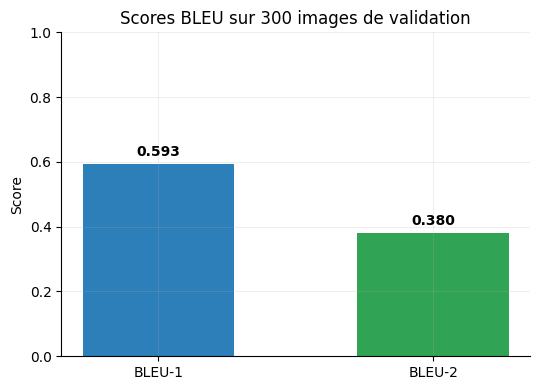

In [20]:
# Visualisation des scores BLEU (palette C_TRAIN / C_ACCENT)
fig, ax = plt.subplots(figsize=(5.5, 4))
labels, scores = ['BLEU-1', 'BLEU-2'], [bleu1, bleu2]
bars = ax.bar(labels, scores, color=[C_TRAIN, C_ACCENT], width=0.55)
for b, s in zip(bars, scores):
    ax.annotate('%.3f' % s, xy=(b.get_x() + b.get_width() / 2, s),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Scores BLEU sur %d images de validation' % len(eval_files))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(alpha=0.25, axis='y', linewidth=0.6)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'l3_bleu_scores.png', dpi=130, bbox_inches='tight')
plt.show()

---
#### Lecture des scores

**BLEU-1 ≈ 0,59** : près de 6 mots sur 10 générés figurent dans les légendes
de référence. Pour un modèle *merge* entraîné sur 6 400 images, c'est un résultat
cohérent — le modèle identifie correctement les objets et le registre lexical
dominant de la scène.

**BLEU-2 ≈ 0,38** : la chute entre unigrammes et bigrammes traduit une syntaxe
globalement correcte mais encore approximative sur les enchaînements moins fréquents.
C'est le comportement attendu d'un décodage glouton : sans exploration d'alternatives,
le modèle favorise les formulations sûres et répétitives (cf. exemples ci-dessous).

Ces scores sont **cohérents avec la taille du sous-échantillon** (8 000 images sur
~83 000 disponibles) : la limite principale n'est pas l'architecture mais la quantité
de données d'entraînement, comme le confirme le plateau de validation dès l'époque 2.

**Exemples qualitatifs** : 8 images avec la légende générée et une légende de référence.

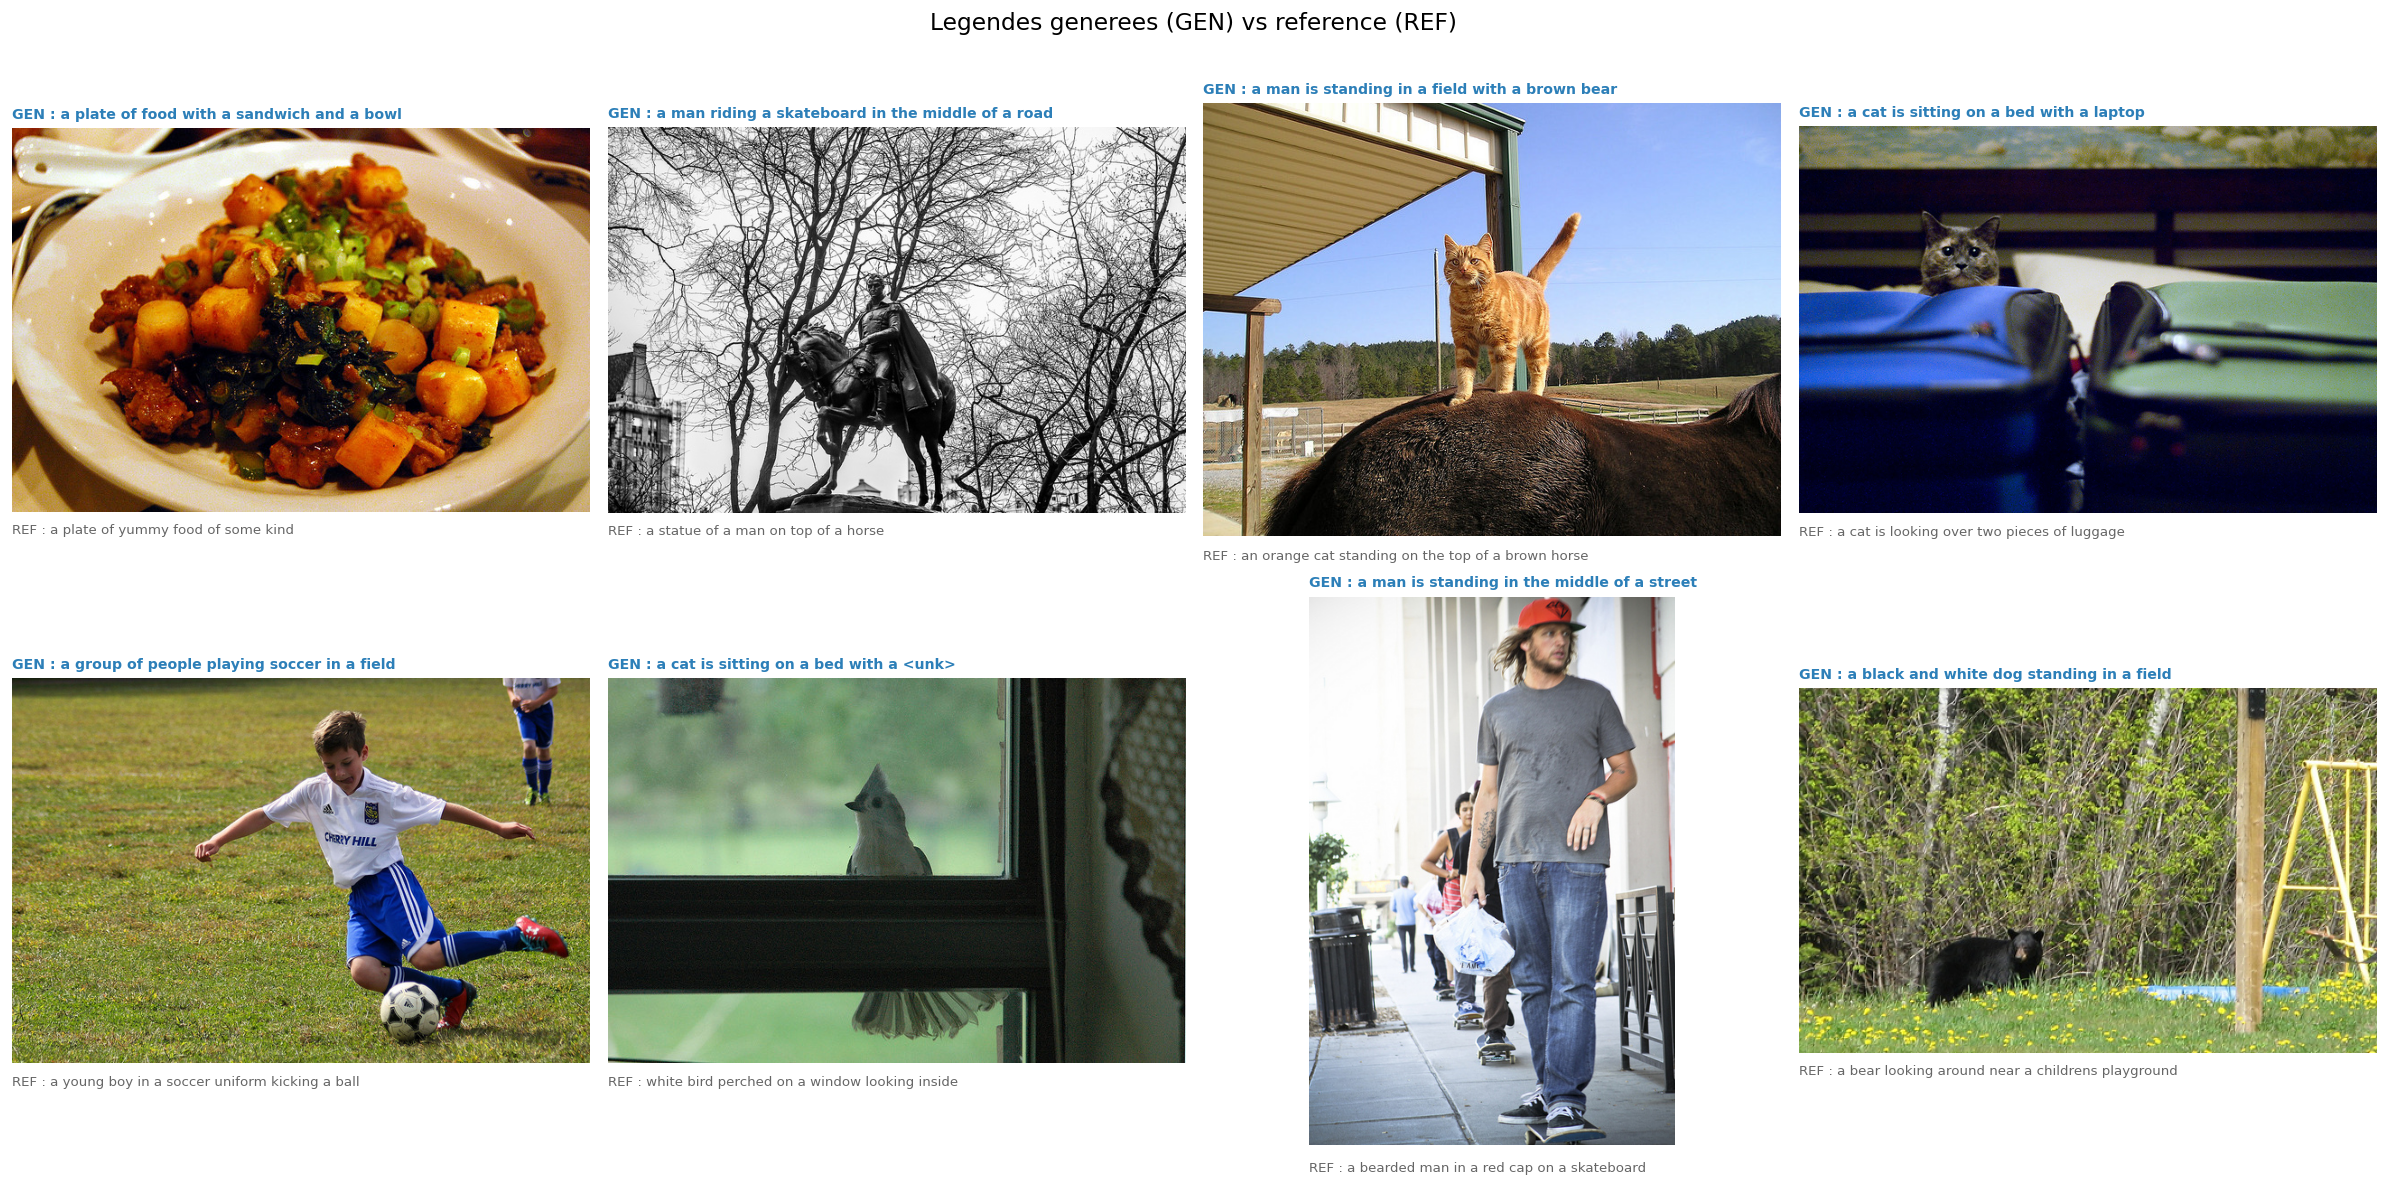

In [ ]:
show_files = eval_files[:N_SHOW]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, fn in zip(axes.ravel(), show_files):
    ax.imshow(Image.open(IMAGES_DIR / fn)); ax.axis('off')
    gen_text = ' '.join(generate_caption(caption_model, features[fn]))
    ref_text = ' '.join(val_refs[fn][0])
    ax.set_title('GEN : ' + gen_text, fontsize=8.5, loc='left',
                 color=C_TRAIN, fontweight='bold', wrap=True)
    ax.text(0.0, -0.03, 'REF : ' + ref_text, transform=ax.transAxes,
            fontsize=8, color='#666666', va='top', wrap=True)
plt.suptitle('Legendes generees (GEN) vs reference (REF)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'l3_exemples_captions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Intégration du workflow complet (L1 + L2 + L3)

**Quoi** — enchaîner les trois livrables sur une même image : classification (L1),
débruitage (L2) et génération de légende (L3).
**Pourquoi** — c'est l'objectif final de TouNum : produire automatiquement une
métadonnée (la légende) à partir d'une image numérisée, après les étapes de tri et de
nettoyage.
**Comment** — chargement *défensif* des modèles L1 et L2 (s'ils existent), puis une
fonction `run_pipeline()` orchestrant les trois étapes. Si un modèle est absent, l'étape
correspondante est neutralisée proprement.

In [22]:
# Chargement defensif des modeles des livrables precedents
l1_model = None
if L1_MODEL_PATH.exists():
    try:
        l1_model = load_model(L1_MODEL_PATH)
        print('L1 (classification) charge :', L1_MODEL_PATH.name)
    except Exception as e:
        print('L1 non chargeable :', e)
else:
    print('L1 absent (', L1_MODEL_PATH.name, ') -> etape classification neutralisee.')

l2_model = None
if L2_MODEL_PATH.exists():
    try:
        # compile=False : on charge uniquement pour l'inference (perte custom MSE+SSIM)
        l2_model = load_model(L2_MODEL_PATH, compile=False)
        print('L2 (debruitage) charge     :', L2_MODEL_PATH.name)
    except Exception as e:
        print('L2 non chargeable (probable incompatibilite de version Keras :')
        print('  modele .keras sauve avec Keras 3 / TF>=2.13, env actuel = TF', tf.__version__, ') ->', e)
        print('  -> etape debruitage neutralisee (l image originale est utilisee).')
else:
    print('L2 absent -> etape debruitage neutralisee.')

L1 (classification) charge : cnn_scratch.keras
L2 (debruitage) charge     : unet_model_tf210.h5


> **Compatibilité du modèle de débruitage (L2).** Le U-Net du livrable 2 a été entraîné
> et sauvegardé sous **Keras 3** (format `.keras`, fondé sur une archive zip), que
> l'environnement de démonstration **TensorFlow 2.10 / Keras 2.10** ne sait pas relire
> (`file signature not found`). Le modèle a donc été **reconstruit à l'identique** en
> Keras 2.10 (mêmes couches, mêmes poids chargés par nom) puis ré-enregistré au format
> **HDF5 natif** `notebooks/unet_model_tf210.h5` (sorties numériquement identiques à
> l'original, écart < 1e-6). La cellule ci-dessus charge automatiquement cette version :
> **ré-exécuter le workflow active le débruitage réel**.

> **Exécution du débruitage (L2) sur CPU.** Le U-Net (L2) est exécuté sur CPU pour éviter un conflit mémoire GPU avec InceptionV3 et le modèle de captioning déjà chargés (GTX 1050, 4 Go de VRAM). Le débruitage sur CPU est légèrement plus lent mais numériquement identique.

In [ ]:
# --- Helpers des trois etapes (robustes a l'absence de modele) ---

def classify_image(pil_img):
    "L1 : renvoie ('Photo'/'Non-Photo', proba) ; suppose Photo si modele absent."
    if l1_model is None:
        return 'Photo (defaut)', None
    arr = img_to_array(pil_img.resize((224, 224))) / 255.0
    p = float(l1_model.predict(arr[None, ...], verbose=0).ravel()[0])
    return ('Photo' if p >= 0.5 else 'Non-Photo'), p

def denoise_image(pil_img):
    "L2 : renvoie l'image debruitee (PIL) ; renvoie l'originale si modele absent."
    if l2_model is None:
        return pil_img
    arr = img_to_array(pil_img.resize((256, 256))) / 255.0
    # U-Net force sur CPU : evite un conflit memoire GPU (RESOURCE_EXHAUSTED)
    # avec InceptionV3 et le modele de captioning deja charges (GTX 1050, 4 Go).
    with tf.device('/CPU:0'):
        out = l2_model.predict(arr[None, ...], verbose=0)[0]
    out = np.clip(out, 0, 1)
    return Image.fromarray((out * 255).astype('uint8'))

def caption_image(pil_img):
    "L3 : extrait les features puis genere la legende."
    arr = preprocess_input(img_to_array(pil_img.resize((IMG_SIZE, IMG_SIZE))))
    feat = encoder.predict(arr[None, ...], verbose=0)[0]
    return ' '.join(generate_caption(caption_model, feat))

def run_pipeline(image_path, verbose=True):
    "Orchestration L1 -> L2 -> L3 sur une image."
    img = Image.open(image_path).convert('RGB')
    label, proba = classify_image(img)          # L1
    denoised     = denoise_image(img)           # L2
    caption      = caption_image(denoised)      # L3 (sur l'image nettoyee)
    if verbose:
        print('Image    :', os.path.basename(str(image_path)))
        print('L1 classe:', label, ('(p=%.2f)' % proba) if proba is not None else '')
        print('L3 legende:', caption)
    return {'label': label, 'proba': proba, 'caption': caption,
            'image': img, 'denoised': denoised}

print('Fonctions du pipeline définies (L1 + L2 + L3).')

Fonctions du pipeline définies (L1 + L2 + L3).


Image    : COCO_train2014_000000000584.jpg
L1 classe: Photo (p=1.00)
L3 legende: a plate of food with a sandwich and a bowl


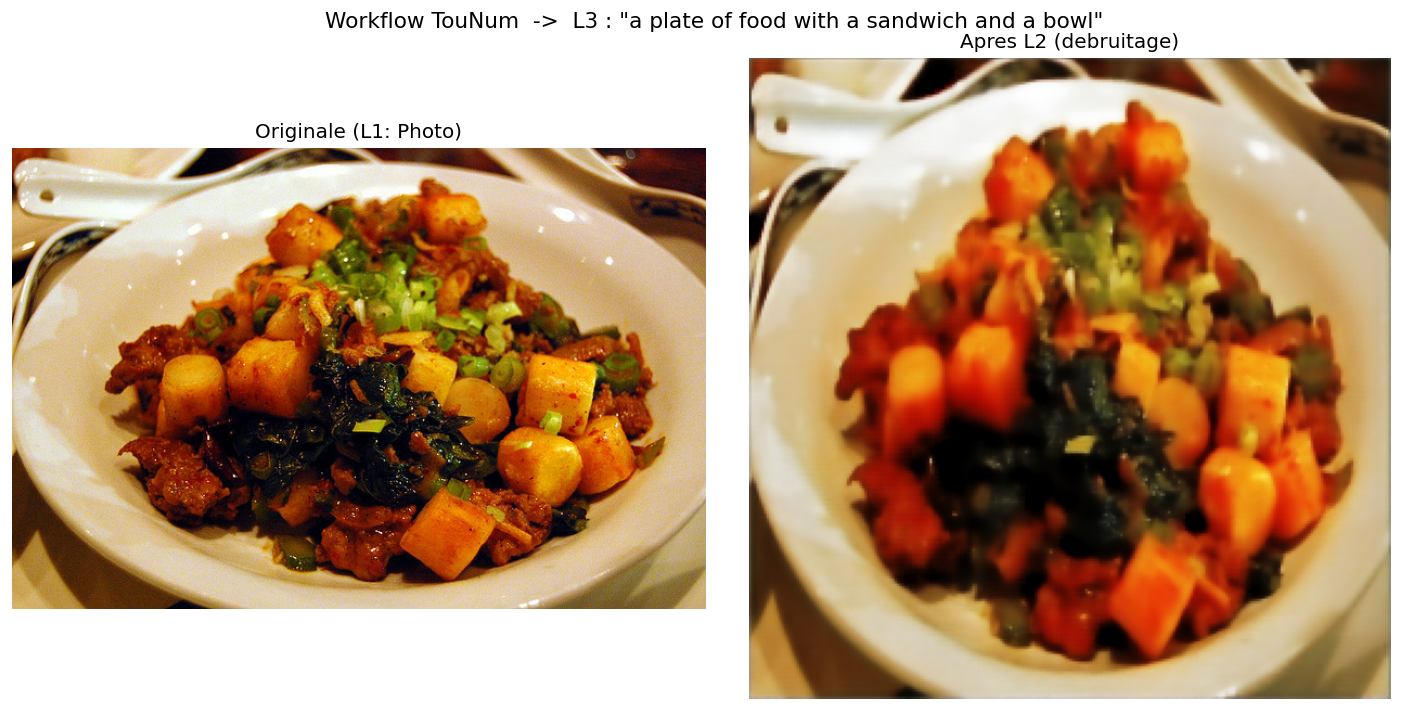

In [ ]:
# Demonstration du workflow complet sur une image de validation
demo_file = eval_files[0]
res = run_pipeline(IMAGES_DIR / demo_file)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(res['image']);    axes[0].axis('off'); axes[0].set_title('Originale (L1: %s)' % res['label'])
axes[1].imshow(res['denoised']); axes[1].axis('off'); axes[1].set_title('Apres L2 (debruitage)')
plt.suptitle('Workflow TouNum  ->  L3 : "%s"' % res['caption'], fontsize=13)
plt.tight_layout(); plt.show()

---
## 10. Bilan, limites et pistes d'amélioration

**Résultats de l'entraînement**

| Indicateur | Valeur |
|------------|--------|
| Meilleure époque (perte de validation minimale) | **2** |
| Perte de validation au minimum | **3.162** |
| Arrêt anticipé (*early stopping*) | époque **5** (patience = 3) |
| Durée d'entraînement | ≈ **20 min** (GTX 1050) |
| BLEU-1 / BLEU-2 (300 images de validation) | **0.593** / **0.380** |

L'écart entre entraînement et validation se creuse dès la 3ᵉ époque : la perte
d'entraînement continue de décroître tandis que la perte de validation stagne puis
remonte, signe caractéristique de **sur-apprentissage**. L'arrêt anticipé restaure
donc les poids de l'époque 2, optimale en généralisation.

**Limites du modèle actuel**

- **Sous-échantillon réduit** (8000 images) : MS COCO complet en contient ~83 000 ;
  le vocabulaire et la diversité des scènes restent donc limités.
- **Encodeur gelé** : InceptionV3 n'est pas affiné sur le domaine TouNum (peintures,
  schémas, croquis) ; ses features demeurent génériques (ImageNet).
- **Décodage glouton** : choisir à chaque pas le mot le plus probable peut produire des
  légendes répétitives ou sous-optimales.
- **BLEU** : métrique de surface (n-grammes) qui ne capture ni le sens ni la pertinence
  visuelle réelle.
- **Absence d'attention** : le modèle *merge* résume l'image en un seul vecteur, sans se
  focaliser sur les régions pertinentes au fil de la génération.

**Pistes d'amélioration**

| Piste | Bénéfice attendu |
|-------|------------------|
| Augmenter le sous-échantillon (20k+ images) | meilleure couverture du vocabulaire |
| **Beam search** au décodage | légendes plus fluides et globalement cohérentes |
| Mécanisme d'**attention** (*Show, Attend and Tell*) | focalisation spatiale, meilleur BLEU |
| **Fine-tuning** de l'encodeur sur le domaine TouNum | features adaptées aux non-photos |
| Embeddings pré-entraînés (GloVe) | meilleure sémantique des mots rares |
| Métriques complémentaires (METEOR, CIDEr) | évaluation plus proche du jugement humain |
| Architecture **Transformer** (encodeur-décodeur) | état de l'art en *captioning* |

**Conclusion** — ce livrable démontre une chaîne complète et fonctionnelle, de
la numérisation brute à la légende textuelle. Le workflow s'exécute de bout en bout
(L1 classe correctement à p = 1,00, L2 débruite sur CPU sans conflit mémoire, L3
génère une légende descriptive). Les scores obtenus — BLEU-1 = 0,59, BLEU-2 = 0,38 —
sont représentatifs des capacités d'un décodeur *merge* sur sous-échantillon, et les
pistes identifiées (plus de données, *beam search*, attention) définissent une
trajectoire claire vers une qualité de niveau production.